# **Imports**

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# **Mount Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Paths**

In [3]:
BASE_DIR = "/content/drive/MyDrive/AI-TeleTriage-System"

SAVE_DIR = os.path.join(BASE_DIR,"saved_objects")
MODEL_DIR = os.path.join(BASE_DIR,"models")

# **Load DataFrames**

In [4]:
with open(os.path.join(SAVE_DIR,"train_df.pkl"),"rb") as f:
    train_df=pickle.load(f)

with open(os.path.join(SAVE_DIR,"val_df.pkl"),"rb") as f:
    val_df=pickle.load(f)

with open(os.path.join(SAVE_DIR,"test_df.pkl"),"rb") as f:
    test_df=pickle.load(f)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(7010, 11)
(1502, 11)
(1503, 11)


# **Load tokenizer**

In [5]:
with open(os.path.join(SAVE_DIR,"tokenizer.pkl"),"rb") as f:
    tokenizer=pickle.load(f)

# **Load padded sequences**

In [6]:
with open(os.path.join(SAVE_DIR,"X_train_pad.pkl"),"rb") as f:
    X_train_pad=pickle.load(f)

with open(os.path.join(SAVE_DIR,"X_val_pad.pkl"),"rb") as f:
    X_val_pad=pickle.load(f)

with open(os.path.join(SAVE_DIR,"X_test_pad.pkl"),"rb") as f:
    X_test_pad=pickle.load(f)

# **Load labels**

In [7]:
with open(os.path.join(SAVE_DIR,"y_train.pkl"),"rb") as f:
    y_train=pickle.load(f)

with open(os.path.join(SAVE_DIR,"y_val.pkl"),"rb") as f:
    y_val=pickle.load(f)

with open(os.path.join(SAVE_DIR,"y_test.pkl"),"rb") as f:
    y_test=pickle.load(f)

# **Load models**

In [8]:
densenet_model = load_model(
    os.path.join(MODEL_DIR,"densenet121_best.keras")
)

bilstm_model = load_model(
    os.path.join(MODEL_DIR,"bilstm_best.keras")
)

# **Verify**

In [9]:
print("DenseNet Loaded")
densenet_model.summary()

print("\nBiLSTM Loaded")
bilstm_model.summary()

DenseNet Loaded


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,493,719 (36.22 MB)

 Trainable params: 1,093,959 (4.17 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 60, 128)        │     1,536,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,522,327 (21.07 MB)

 Trainable params: 1,840,775 (7.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,681,552 (14.04 MB)

# **Image Generator**

In [11]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 64

test_datagen = ImageDataGenerator(rescale=1./255)

# **Train Generator**

In [12]:
train_generator = test_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="path",
    y_col=None,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

Found 7010 validated image filenames.


# **Validation Generator**

In [13]:
val_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="path",
    y_col=None,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

Found 1502 validated image filenames.


# **Test Generator**

In [14]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="path",
    y_col=None,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

Found 1503 validated image filenames.


# **Build DenseNet Feature Extractor**

In [15]:
image_feature_extractor = Model(
    inputs=densenet_model.input,
    outputs=densenet_model.layers[-2].output
)

# **Check Output Shape**

In [16]:
image_feature_extractor.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,304,000 (27.86 MB)

 Trainable params: 1,092,160 (4.17 MB)

 Non-trainable params: 6,211,840 (23.70 MB)

# **Extract Image Features**

In [17]:
image_train_features = image_feature_extractor.predict(
    train_generator,
    verbose=1
)

image_val_features = image_feature_extractor.predict(
    val_generator,
    verbose=1
)

image_test_features = image_feature_extractor.predict(
    test_generator,
    verbose=1
)

110/110 ━━━━━━━━━━━━━━━━━━━━ 1825s 17s/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 369s 16s/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 402s 17s/step


# **Verify Shapes**

In [18]:
print(image_train_features.shape)
print(image_val_features.shape)
print(image_test_features.shape)

(7010, 256)
(1502, 256)
(1503, 256)


# **Build BiLSTM Feature Extractor**

In [20]:
print(bilstm_model.inputs)
print(bilstm_model.input_shape)

[<KerasTensor shape=(None, 60), dtype=float32, sparse=False, ragged=False, name=input_layer>]
(None, 60)


In [21]:
text_feature_extractor = tf.keras.Model(
    inputs=bilstm_model.inputs,
    outputs=bilstm_model.layers[-2].output
)

# **Verify**

In [22]:
text_feature_extractor.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 60, 128)        │     1,536,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,840,320 (7.02 MB)

 Trainable params: 1,840,320 (7.02 MB)

 Non-trainable params: 0 (0.00 B)

# **Extract Text Features**

In [23]:
text_train_features = text_feature_extractor.predict(
    X_train_pad,
    verbose=1
)

text_val_features = text_feature_extractor.predict(
    X_val_pad,
    verbose=1
)

text_test_features = text_feature_extractor.predict(
    X_test_pad,
    verbose=1
)

220/220 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step


# **Verify**

In [24]:
print(text_train_features.shape)
print(text_val_features.shape)
print(text_test_features.shape)

(7010, 64)
(1502, 64)
(1503, 64)


# **Combine Features**

In [25]:
X_train_fusion = np.concatenate(
    [image_train_features, text_train_features],
    axis=1
)

X_val_fusion = np.concatenate(
    [image_val_features, text_val_features],
    axis=1
)

X_test_fusion = np.concatenate(
    [image_test_features, text_test_features],
    axis=1
)

# **Final Check**

In [26]:
print(X_train_fusion.shape)
print(X_val_fusion.shape)
print(X_test_fusion.shape)

(7010, 320)
(1502, 320)
(1503, 320)


In [28]:
image_train_features.shape


(7010, 256)

In [29]:

text_train_features.shape


(7010, 64)

In [30]:

X_train_fusion.shape

(7010, 320)

# **Build Fusion Model**

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization

fusion_model = Sequential([

    Input(shape=(320,)),   # 256 image + 64 text

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(7, activation="softmax")

])

fusion_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,319 (489.53 KB)

 Trainable params: 124,551 (486.53 KB)

 Non-trainable params: 768 (3.00 KB)

# **Compile**

In [32]:
fusion_model.compile(

    optimizer=tf.keras.optimizers.Adam(1e-4),

    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.05
    ),

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# **Callbacks**

In [33]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    os.path.join(MODEL_DIR, "fusion_best.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]

# **Train**

In [34]:
history = fusion_model.fit(

    X_train_fusion,
    y_train,

    validation_data=(
        X_val_fusion,
        y_val
    ),

    epochs=20,
    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/20
218/220 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2053 - loss: 2.4940 - precision: 0.2412 - recall: 0.1049
Epoch 1: val_accuracy improved from None to 0.78828, saving model to /content/drive/MyDrive/AI-TeleTriage-System/models/fusion_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI-TeleTriage-System/models/fusion_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3233 - loss: 2.0729 - precision: 0.4104 - recall: 0.1900 - val_accuracy: 0.7883 - val_loss: 1.1223 - val_precision: 0.9955 - val_recall: 0.2956 - learning_rate: 1.0000e-04
Epoch 2/20
215/220 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5967 - loss: 1.2729 - precision: 0.7378 - recall: 0.4536
Epoch 2: val_accuracy improved from 0.78828 to 0.93076, saving model to /content/drive/MyDrive/AI-TeleTriage-System/models/fusion_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI-TeleTriage-System/models/fusion_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/st

# **Evaluate**

In [35]:
results = fusion_model.evaluate(
    X_test_fusion,
    y_test,
    verbose=1
)

print("\nTest Accuracy :", results[1])
print("Precision :", results[2])
print("Recall :", results[3])

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9647 - loss: 0.3586 - precision: 0.9768 - recall: 0.9534

Test Accuracy : 0.9647371768951416
Precision : 0.9768234491348267
Recall : 0.9534264802932739


# **Predictions**

In [36]:
pred_prob = fusion_model.predict(X_test_fusion)

pred_classes = np.argmax(pred_prob, axis=1)

true_classes = np.argmax(y_test, axis=1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


# **Classification Report**

In [37]:
class_names = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
]

print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

       akiec       0.66      0.59      0.62        49
         bcc       0.67      0.83      0.74        77
         bkl       1.00      1.00      1.00       165
          df       0.80      0.24      0.36        17
         mel       1.00      1.00      1.00       167
          nv       1.00      1.00      1.00      1006
        vasc       0.75      0.68      0.71        22

    accuracy                           0.96      1503
   macro avg       0.84      0.76      0.78      1503
weighted avg       0.97      0.96      0.96      1503



# **Confusion Matrix**

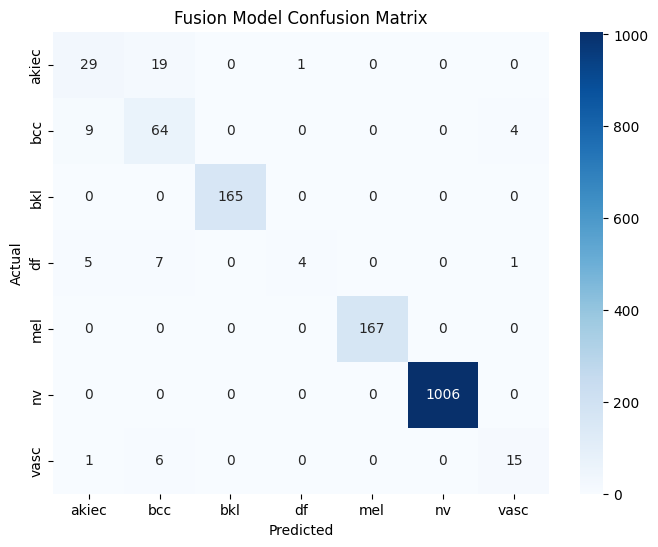

In [38]:
cm = confusion_matrix(
    true_classes,
    pred_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fusion Model Confusion Matrix")

plt.show()

# **Save the fusion artifacts.**

In [39]:
fusion_model.save(
    os.path.join(MODEL_DIR, "fusion_final.keras")
)

with open(os.path.join(SAVE_DIR,"fusion_history.pkl"),"wb") as f:
    pickle.dump(history.history,f)

with open(os.path.join(SAVE_DIR,"fusion_class_names.pkl"),"wb") as f:
    pickle.dump(class_names,f)

print("Fusion model saved successfully.")

Fusion model saved successfully.


# **Save Final Fusion Model**

In [40]:
fusion_model.save(
    os.path.join(MODEL_DIR, "fusion_final.keras")
)

# **Save Training History**

In [41]:
with open(os.path.join(SAVE_DIR, "fusion_history.pkl"), "wb") as f:
    pickle.dump(history.history, f)

# **Save Class Names**

In [42]:
class_names = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
]

with open(os.path.join(SAVE_DIR, "fusion_class_names.pkl"), "wb") as f:
    pickle.dump(class_names, f)

# **Accuracy Curve**

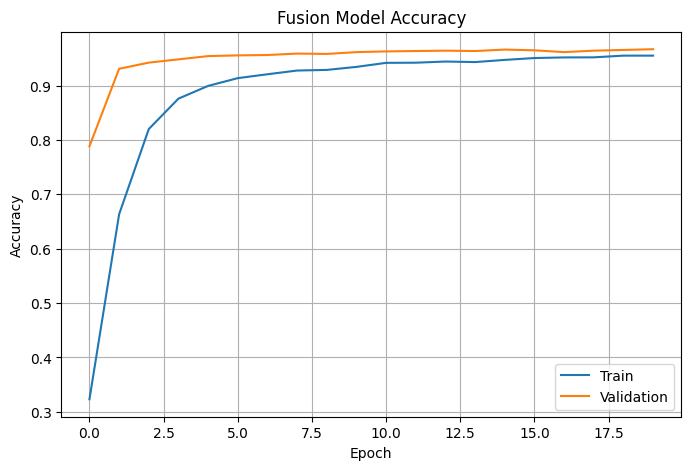

In [43]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Fusion Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# **Loss Curve**

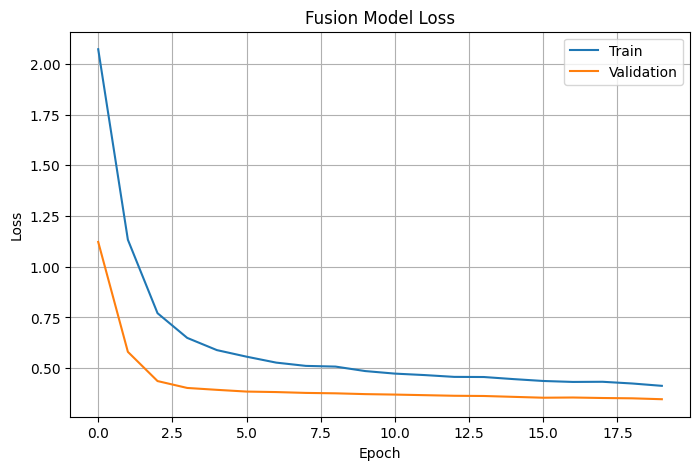

In [44]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.title("Fusion Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# **Precision Curve**

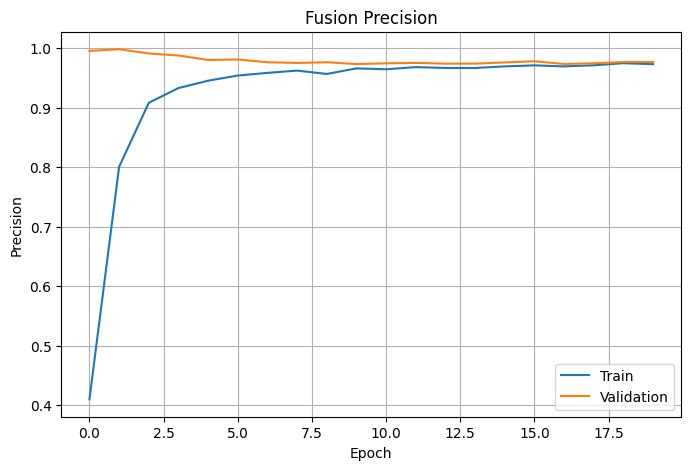

In [45]:
plt.figure(figsize=(8,5))

plt.plot(history.history["precision"], label="Train")
plt.plot(history.history["val_precision"], label="Validation")

plt.title("Fusion Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)

plt.show()

# **Recall Curve**

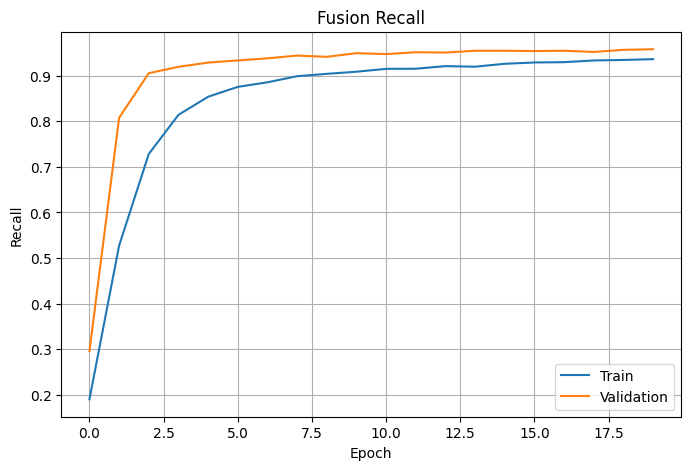

In [46]:
plt.figure(figsize=(8,5))

plt.plot(history.history["recall"], label="Train")
plt.plot(history.history["val_recall"], label="Validation")

plt.title("Fusion Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()
plt.grid(True)

plt.show()

# **Multi-class ROC Curve**

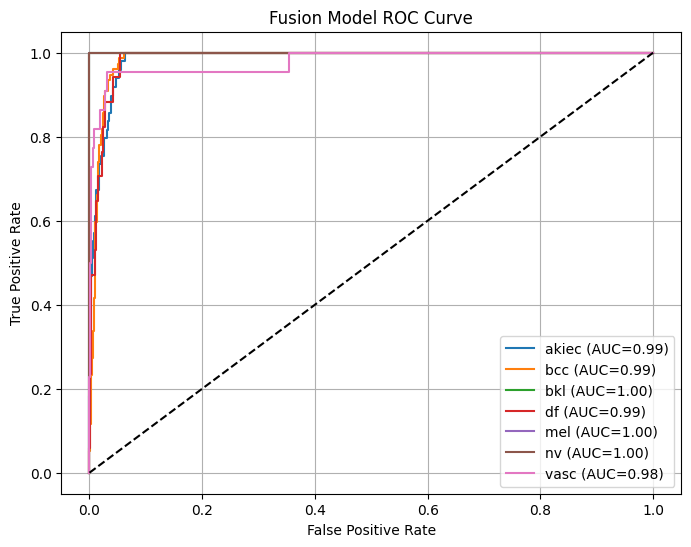

In [47]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true = label_binarize(true_classes, classes=range(7))

plt.figure(figsize=(8,6))

for i in range(7):
    fpr, tpr, _ = roc_curve(y_true[:, i], pred_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr,
             label=f"{class_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fusion Model ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

# **Save Prediction Probabilities**

In [48]:
pickle.dump(
    pred_prob,
    open(os.path.join(SAVE_DIR,"fusion_predictions.pkl"),"wb")
)